In [3]:
# pip install seaborn

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [6]:
df= pd.read_csv("Bus Fare.csv")
df.head()

,Bus Name,Passanger Age,Distance Travel(km),Bus fare
0,V.I.P,17,22,30
1,Bolaka,34,25,60
2,Gajipur Poribohon,19,32,75
3,United,23,30,80
4,Bolaka,17,17,20


In [9]:
df.columns

Index(['name', ' Passanger Age', 'distance', 'fare'], dtype='object')

In [10]:
df = df.rename(columns={"Bus Name":"name", " Passanger Age": "p_age", "Distance Travel(km)": "distance", "Bus fare":"fare"})

In [11]:
df.head()

,name,p_age,distance,fare
0,V.I.P,17,22,30
1,Bolaka,34,25,60
2,Gajipur Poribohon,19,32,75
3,United,23,30,80
4,Bolaka,17,17,20


In [12]:
df["name"].value_counts()

name
V.I.P                4
Bolaka               4
Gajipur Poribohon    4
United               4
Tawqa                4
Provati              4
Name: count, dtype: int64

In [13]:
df.shape

(24, 4)

In [14]:
df.isna().sum()

name        0
p_age       0
distance    0
fare        0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   name      24 non-null     object
 1   p_age     24 non-null     int64 
 2   distance  24 non-null     int64 
 3   fare      24 non-null     int64 
dtypes: int64(3), object(1)
memory usage: 900.0+ bytes


In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [18]:
df["name"]= le.fit_transform(df["name"])
df.head()

,name,p_age,distance,fare
0,5,17,22,30
1,0,34,25,60
2,1,19,32,75
3,4,23,30,80
4,0,17,17,20


In [19]:
df.corr()

,name,p_age,distance,fare
name,1.000000,-0.147713,0.017645,0.044494
p_age,-0.147713,1.000000,-0.121744,0.143343
distance,0.017645,-0.121744,1.000000,0.753547
fare,0.044494,0.143343,0.753547,1.000000


<Axes: xlabel='distance', ylabel='fare'>

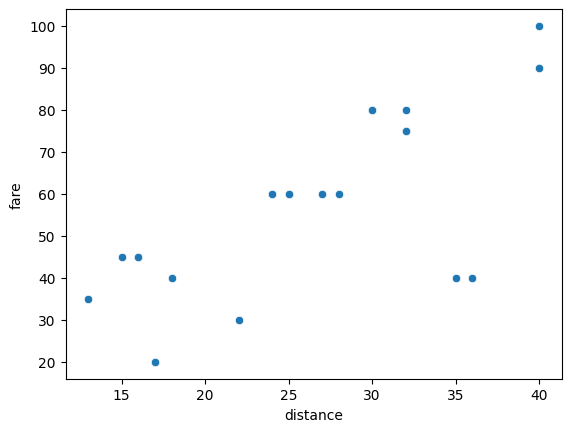

In [21]:
# scatter plot 
sns.scatterplot(x=df["distance"], y =df["fare"])

In [22]:
# separate the data
x =df.drop(["fare"], axis=1)
y =df[["fare"]]

In [23]:
x.head()

,name,p_age,distance
0,5,17,22
1,0,34,25
2,1,19,32
3,4,23,30
4,0,17,17


In [24]:
y.head()

,fare
0,30
1,60
2,75
3,80
4,20


In [46]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
lr = LinearRegression()
xtrain,xtest,ytrain,ytest = train_test_split(x,y, test_size=.15)

In [47]:
model = lr.fit(xtrain, ytrain)
model.score(xtrain, ytrain)

0.6201137609394116

In [48]:
model.score(xtest, ytest)

0.5998443634761519

In [49]:
#evaluate
xtest

,name,p_age,distance
6,5,27,16
13,1,15,17
14,0,18,32
20,2,15,30


In [50]:
y_pred = model.predict(xtest)
y_pred

array([[45.61233969],
       [30.92930032],
       [60.30784934],
       [57.19003664]])

In [51]:
ytest

,fare
6,45
13,20
14,80
20,80


In [54]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
sc= r2_score(ytest, y_pred)

In [53]:
sc

0.5998443634761519

In [55]:
# cost calculate
mse = mean_squared_error(ytest, y_pred)
mse

256.97494783015867

In [56]:
xtrain.head()

,name,p_age,distance
17,4,17,40
5,1,40,24
0,5,17,22
18,3,34,16
8,2,33,27


In [58]:
ytrain.head()

,fare
17,90
5,60
0,30
18,45
8,60


In [60]:
# test the model 
model.predict([[5,	17,	22]])

c:\Users\CreativeIT\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[48.53043924]])

In [61]:
# user input 
dic= {"name": [4],
      "p_age": [22],
      "distance": [45]}

dic

{'name': [4], 'p_age': [22], 'distance': [45]}

In [62]:
data = pd.DataFrame(dic)
data

,name,p_age,distance
0,4,22,45


In [65]:
fare_pred= model.predict(data)

In [66]:
print("predicted fare is ", fare_pred)

predicted fare is  [[94.77286432]]


V.I.P                4
Bolaka               4
Gajipur Poribohon    4
United               4
Tawqa                4
Provati              4

In [67]:
df["name"].value_counts()

name
5    4
0    4
1    4
4    4
3    4
2    4
Name: count, dtype: int64

In [70]:
Name =int(input("give the bus name 5 for vip, 0for bolaka,1for gazipur"))
P_age = int(input("enter any valid value between 1-80"))
dis= float(input("enter value as distance in km"))

data = [Name, P_age, dis]

In [71]:
data

[5, 22, 35.0]

In [73]:
model.predict([data])

c:\Users\CreativeIT\anaconda3\envs\myenv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([[77.41486071]])

In [74]:
import pickle
pickle.dump(model, open("bus_fare.pkl","wb"))